In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier,DecisionTreeRegressor
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.metrics import accuracy_score,log_loss,r2_score
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression,LinearRegression,ElasticNet
from sklearn.ensemble import BaggingRegressor,RandomForestRegressor
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.compose import ColumnTransformer
from sklearn.compose import make_column_selector
from tqdm import tqdm
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeClassifier,plot_tree

In [8]:
house=pd.read_csv("D:\\AshleshaRuchika\\PGCP-AI\\Machine Learning\\Datasets\\Housing.csv")
house

,price,lotsize,bedrooms,bathrms,stories,driveway,recroom,fullbase,gashw,airco,garagepl,prefarea
0,42000.0,5850,3,1,2,yes,no,yes,no,no,1,no
1,38500.0,4000,2,1,1,yes,no,no,no,no,0,no
2,49500.0,3060,3,1,1,yes,no,no,no,no,0,no
3,60500.0,6650,3,1,2,yes,yes,no,no,no,0,no
4,61000.0,6360,2,1,1,yes,no,no,no,no,0,no
...,...,...,...,...,...,...,...,...,...,...,...,...
541,91500.0,4800,3,2,4,yes,yes,no,no,yes,0,no
542,94000.0,6000,3,2,4,yes,no,no,no,yes,0,no
543,103000.0,6000,3,2,4,yes,yes,no,no,yes,1,no
544,105000.0,6000,3,2,2,yes,yes,no,no,yes,1,no


In [9]:
X,y=house.drop("price",axis=1),house["price"]
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=26)

In [10]:
ohe=OneHotEncoder(sparse_output=False,drop="first").set_output(transform="pandas")
transf=ColumnTransformer(transformers=[("OHE",ohe, make_column_selector
                                        (dtype_include=object))],remainder="passthrough",verbose_feature_names_out=False).set_output(transform="pandas")
X_trn_ohe=transf.fit_transform(X_train)
X_tst_ohe=transf.transform(X_test)

In [17]:
features=[2,3,4,5,6,7]
scores=[]
for f in tqdm(features):
    for n in [25,50,75,100,125]:
        rf=RandomForestRegressor(random_state=26,max_features=f,n_estimators=n)
        rf.fit(X_trn_ohe,y_train)
        y_pred=rf.predict(X_tst_ohe)
        scores.append([f,n,r2_score(y_test,y_pred)])
df_scores=pd.DataFrame(scores,columns=["Model","n_est","score"])
df_scores.sort_values("score",sort_values=ascending)
       

100%|████████████████████████████████████████████████████████████████████████████████████| 6/6 [00:04<00:00,  1.29it/s]


NameError: name 'ascending' is not defined

In [ ]:
bm=RandomForestClassifier(random_state=26,max_features=7,n_estimators=25)
bm.fit(X_trn_ohe,y_train)
y_pred_prob=bm.predict_proba(X_tst_ohe)
y_pred=bm.predict(X_trn_ohe)
y_pred

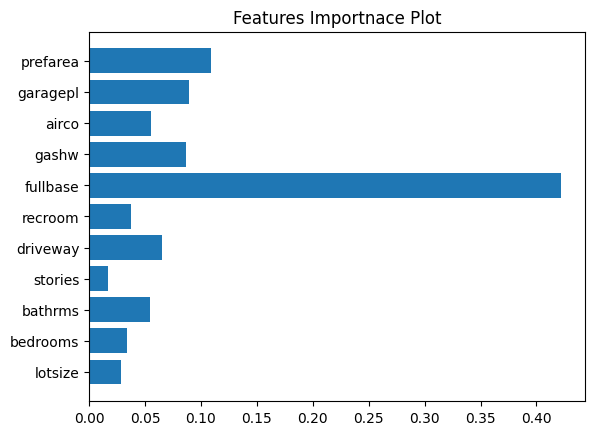

In [16]:
df_imp=pd.DataFrame({"feature":X.columns,"importance": bm.feature_importances_})
plt.barh(df_imp["feature"],df_imp["importance"])
plt.title("Features Importnace Plot")
plt.show()